## Atmospheric Carbon Dioxide Dry Air Mole Fractions from quasi-continuous measurements at Mauna Loa, Hawaii.

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from darts import TimeSeries
from darts.dataprocessing.transformers.boxcox import BoxCox, FittableDataTransformer
from darts.utils.statistics import extract_trend_and_seasonality, ModelMode


sns.set_style("whitegrid")
Path.cwd()
data_dir = (Path.cwd().parent / ".data").resolve()
assert data_dir.exists()

/var/folders/yl/_h6j91qd4d30w8vyy7hnlvjh0000gn/T/ipykernel_40828/3935367952.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd.read_csv(
/var/folders/yl/_h6j91qd4d30w8vyy7hnlvjh0000gn/T/ipykernel_40828/3935367952.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M').mean()
The provided DatetimeIndex was associated with a timezone, which is currently not supported by xarray. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 600 entries, 1974-05-31 00:00:00+00:00 to 2024-04-30 00:00:00+00:00
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   600 non-null    float64
dtypes: float64(1)
memory usage: 9.4 KB
None


<Axes: xlabel='date'>

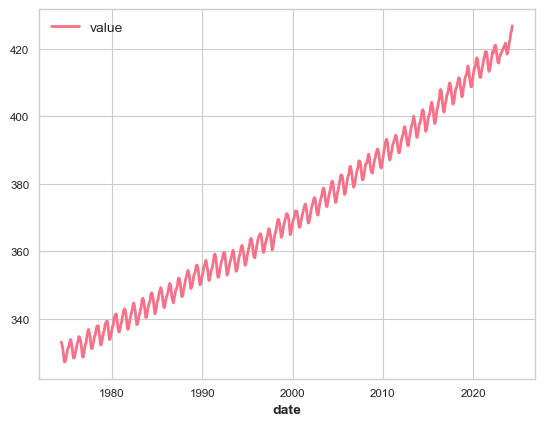

In [13]:
ts = (
    pd.read_csv(
        data_dir / "co2_mlo_surface-insitu_1_ccgg_DailyData.csv",
        delim_whitespace=True,
        header=158,
    )
    .assign(date=lambda df: pd.to_datetime(df['datetime']))
    .drop(columns=["year", "month", "day", "hour", "minute", "second", "datetime", "time_decimal", "midpoint_time"]) # drop redundant cols
    # replace invalid values with NaN
    .assign(
        **{
            col: lambda df, col=col: pd.to_numeric(df[col], errors='coerce').where(df[col] >= 0) for col in ("value", "value_std_dev", "intake_height")
        }
    )
    [["date", "value"]]
    .drop_duplicates(subset=["date"])
    .set_index("date")
    .resample('M').mean()
    # interpolate missing values, TODO: suboptimal predictions
    .interpolate(method='time')
    # drop NaNs at the end and beginning
    .dropna()
    .pipe(lambda df: print(df.info()) or df)
    .pipe(
        lambda df: TimeSeries.from_dataframe(
            df, value_cols=["value"], fill_missing_dates=True,
        )
    )
)

ts.plot()

### Ex 6
Use the MONTHLY AGGREGATED data (i.e. with a yearmonth date format) from your case
study for this exercise.
- Produce forecasts for your time series using `NAIVE(y)`, `SNAIVE(y)` and `RW(y ~ drift())`. Plot the resulting forecasts with prediction intervals and including the historical data. Is any of these methods appropriate here?
- Try to do a clever transformation of your time series and then forecast the transformed time series using `NAIVE(y)`, `SNAIVE(y)` and `RW(y ~ drift())`. Plot the resulting forecasts with prediction intervals and including the historical data. Is any of these methods appropriate now?
- Choose your favorite forecast and focus on the residuals. Do the residuals look like white noise?
- Tidy up your code, such that you would be happy to share it in class.

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.


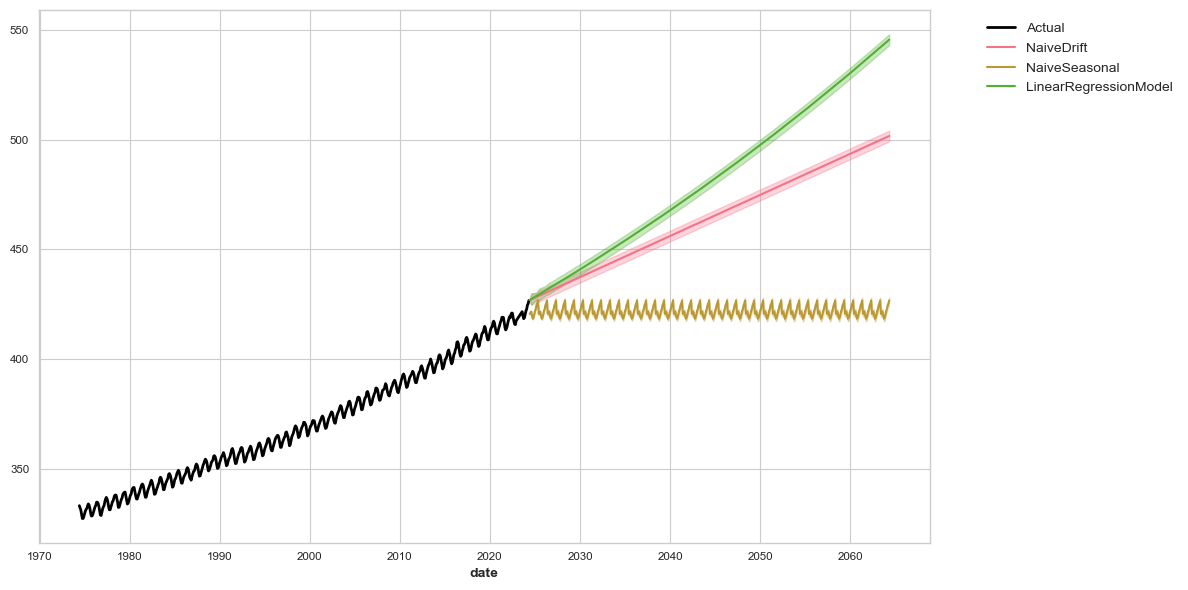

In [14]:
from darts.models import NaiveDrift, NaiveSeasonal, NaiveMean, LinearRegressionModel
from darts.models.forecasting.forecasting_model import ForecastingModel
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("husl")

forecast_horizon = 12 * 40

models = [
    NaiveDrift(),
    NaiveSeasonal(K=12),
    LinearRegressionModel(lags=1)
]

# Forecast

def fit_predict(ts_train: TimeSeries, models: list[ForecastingModel], forecast_horizon: int) -> dict[str, tuple[TimeSeries, np.ndarray, np.ndarray]]:
    forecasts = {}
    for model in models:
        model.fit(ts_train)
        pred = model.predict(forecast_horizon)

        # Calculate residuals on training data
        res = model.residuals(ts_train)
        std_dev = np.array([np.std(res.values()[:h]) for h in range(1, forecast_horizon + 1)])

        # Confidence intervals
        ci_low = pred - 1.96 * std_dev[:, None, None]
        ci_high = pred + 1.96 * std_dev[:, None, None]

        forecasts[model.__class__.__name__] = (pred, ci_low, ci_high)
    return forecasts

def plot_forecast(ts: TimeSeries, forecasts: dict[str, tuple[TimeSeries, np.ndarray, np.ndarray]], tf: FittableDataTransformer = None):
    plt.figure(figsize=(12, 6))
    if tf is not None:
        ts = tf.inverse_transform(ts)
    ts.plot(label='Actual', lw=2, color='black')

    for name, (forecast, ci_low, ci_high) in forecasts.items():
        color = sns.color_palette()[list(forecasts.keys()).index(name)]

        # Plot forecast line
        if tf is not None:
            forecast = tf.inverse_transform(forecast)
            ci_low = tf.inverse_transform(ci_low)
            ci_high = tf.inverse_transform(ci_high)
        forecast.plot(label=f'{name}', color=color, lw=1.5)

        # Plot confidence interval
        plt.fill_between(
            forecast.time_index,
            ci_low.values().flatten(),
            ci_high.values().flatten(),
            alpha=0.3,
            color=color
        )

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

forecasts = fit_predict(ts, models, forecast_horizon)
plot_forecast(ts, forecasts)

- Try to do a clever transformation of your time series and then forecast the transformed time series using `NAIVE(y)`, `SNAIVE(y)` and `RW(y ~ drift())`. Plot the resulting forecasts with prediction intervals and including the historical data. Is any of these methods appropriate now?

In [15]:
from darts.dataprocessing.transformers.boxcox import BoxCox

boxcox = BoxCox().fit(ts)
opt_lmbda = boxcox._fitted_params[0][0]
print(
    f"optimal lambda: {opt_lmbda}",
)

tf_ts = boxcox.transform(ts)

optimal lambda: -1.4303653756088262


`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.


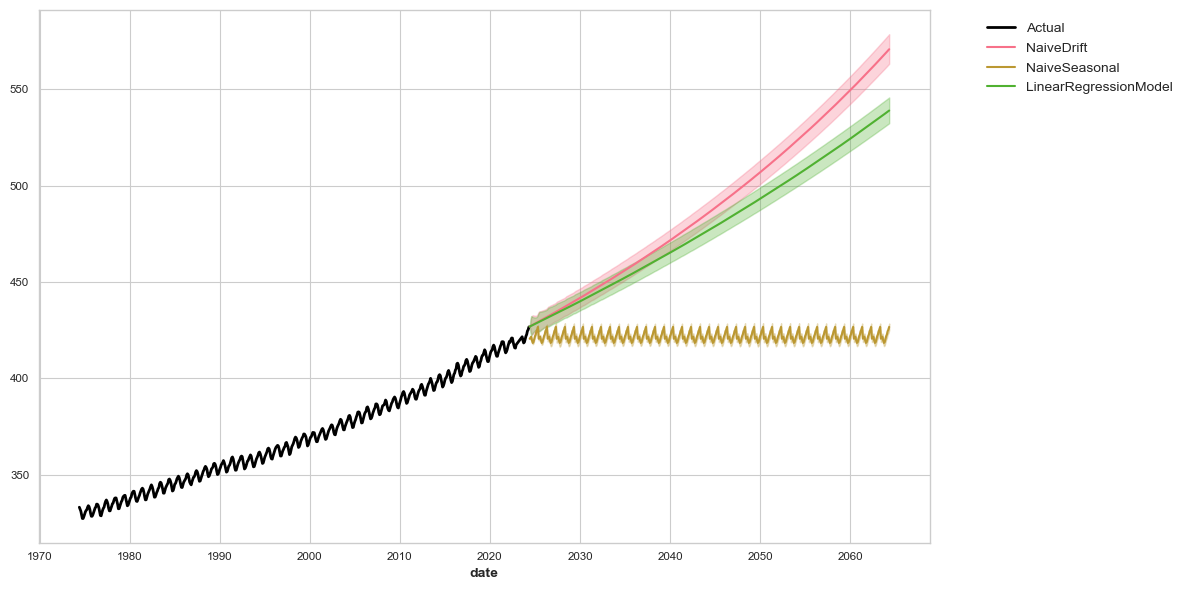

In [16]:
models = [
    NaiveDrift(),
    NaiveSeasonal(K=12),
    LinearRegressionModel(lags=1)
]

forecasts = fit_predict(tf_ts, models, forecast_horizon)
plot_forecast(tf_ts, forecasts, tf=boxcox)

In [17]:
naive_drift = NaiveDrift()
naive_drift.fit(tf_ts)
residuals = naive_drift.residuals(tf_ts)

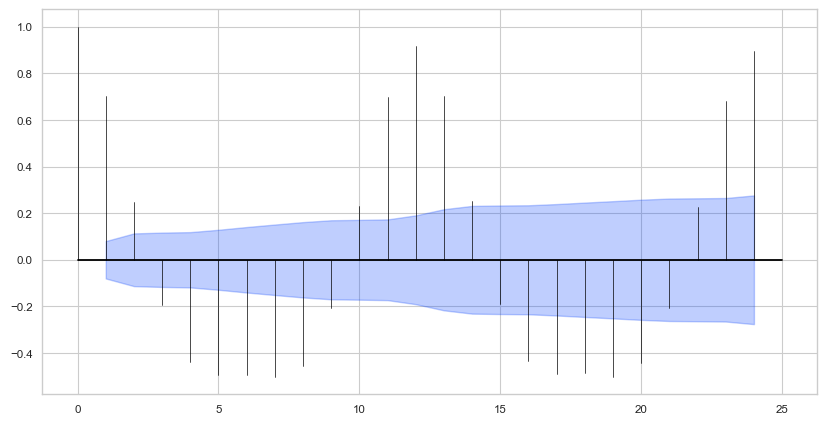

In [18]:
from darts.utils.statistics import plot_acf

plot_acf(boxcox.inverse_transform(residuals))

<Axes: xlabel='time'>

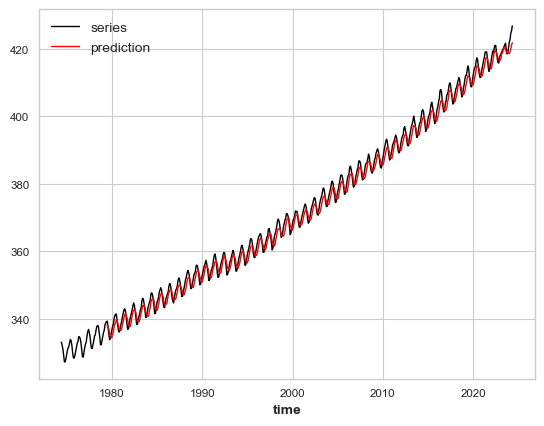

In [19]:
from darts.models import NaiveEnsembleModel
from darts.metrics import mape

naive_ensemble = NaiveEnsembleModel(
    forecasting_models=[NaiveSeasonal(K=12), NaiveDrift()]
)

backtest = naive_ensemble.historical_forecasts(tf_ts, start=0.1, forecast_horizon=3)

boxcox.inverse_transform(tf_ts).plot(label="series", color="black", lw=1)
boxcox.inverse_transform(backtest).plot(label="prediction", color="red", lw=1)

In [20]:
# tf_ts = tf_ts.split_after(pd.Timestamp("01.06.2021"))[0]

<Axes: xlabel='date'>

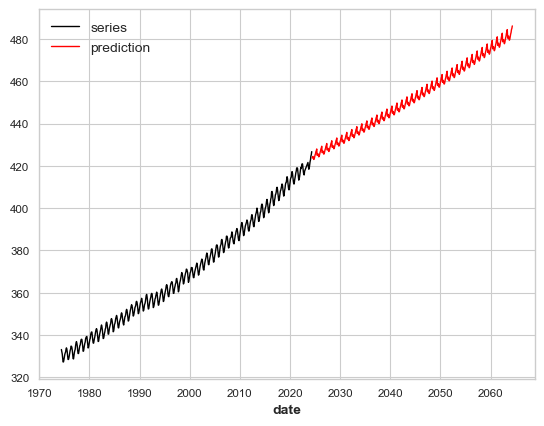

In [21]:
naive_ensemble.fit(tf_ts)
forecast = naive_ensemble.predict(forecast_horizon)

boxcox.inverse_transform(tf_ts).plot(label="series", color="black", lw=1)
boxcox.inverse_transform(forecast).plot(label="prediction", color="red", lw=1)

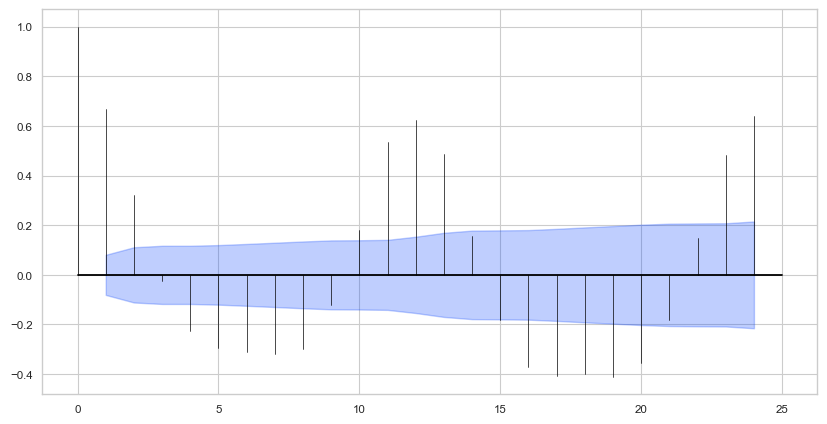

In [24]:
naive_ensemble.fit(tf_ts)
residuals = naive_ensemble.residuals(tf_ts)
plot_acf(boxcox.inverse_transform(residuals))